# Model Improvement and Data Augmentation (Milestone-3)

In this notebook, we improve the segmentation model performance by:

- Applying data augmentation
- Implementing an improved UNet architecture
- Training with optimized hyperparameters
- Evaluating validation IoU
- Visualizing improved predictions

This milestone focuses on improving model accuracy and segmentation quality.

## 1. Import Libraries

Import required libraries for dataset loading, model training, augmentation, and visualization.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import cv2

from torch.utils.data import DataLoader, Subset, random_split
from pycocotools.coco import COCO

import sys
sys.path.append(os.path.abspath(".."))

from src.dataset import CocoSegmentationDataset

## 2. Load COCO Dataset

Load COCO annotations and initialize dataset.

In [2]:
annotation_path = "../data/annotations/instances_train2017.json"
image_folder = "../data/train2017"

coco = COCO(annotation_path)

loading annotations into memory...
Done (t=13.31s)
creating index...
index created!


## 3. Apply Data Augmentation

Data augmentation increases dataset diversity and improves generalization.

In [3]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256,256)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

mask_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(
        (256,256),
        interpolation=transforms.InterpolationMode.NEAREST
    ),
    transforms.ToTensor()
])

## 4. Create Dataset and DataLoader

In [4]:
dataset = CocoSegmentationDataset(
    coco,
    image_folder,
    image_transform=train_transform,
    mask_transform=mask_transform
)

small_dataset = Subset(dataset, range(300))

train_ds, val_ds = random_split(
    small_dataset,
    [240,60],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False
)

## 5. Mask Cleaning

Remove small noise using morphological operations.

In [5]:
def clean_mask(mask):

    mask_np = mask.squeeze().cpu().numpy().astype(np.uint8)

    kernel = np.ones((5,5), np.uint8)

    cleaned = cv2.morphologyEx(
        mask_np,
        cv2.MORPH_CLOSE,
        kernel
    )

    return cleaned

## 6. Improved UNet Architecture

This model includes dropout layers to reduce overfitting.

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Dropout(0.2)
        )

    def forward(self, x):
        return self.conv(x)


class ImprovedUNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        # Final Layer
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        # Encoder
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        # Bottleneck
        bn = self.bottleneck(p3)

        # Decoder
        up3 = self.up3(bn)
        up3 = torch.cat([up3, d3], dim=1)
        up3 = self.conv3(up3)

        up2 = self.up2(up3)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.conv2(up2)

        up1 = self.up1(up2)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.conv1(up1)

        output = self.final(up1)

        return output

## 7. Training Setup

Initialize optimizer and loss function.

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = ImprovedUNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

criterion = nn.BCEWithLogitsLoss()

## 8. Train Improved Model

In [ ]:
num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        masks = masks.float()

        outputs = model(images)

        loss = criterion(outputs, masks)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {total_loss/len(train_loader):.4f}"
    )

Epoch 1, Loss: 0.1408
Epoch 2, Loss: 0.0112
Epoch 3, Loss: 0.0084
Epoch 4, Loss: 0.0066
Epoch 5, Loss: 0.0059


## 9. Compute Validation IoU

In [ ]:
def evaluate_iou(model, loader):

    model.eval()

    total_iou = 0

    with torch.no_grad():

        for images, masks in loader:

            outputs = model(images)

            preds = (
                torch.sigmoid(outputs) > 0.1
            ).float()

            intersection = (
                preds * masks
            ).sum()

            union = (
                preds + masks
            ).sum() - intersection

            iou = (
                intersection /
                (union + 1e-6)
            )

            total_iou += iou

    return total_iou / len(loader)


iou_score = evaluate_iou(
    model,
    val_loader
)

print("Validation IoU:", iou_score.item())

Validation IoU: 0.0


## 10. Visualize Predictions

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.0996952].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0648367].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..1.8382572].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..1.9776908].


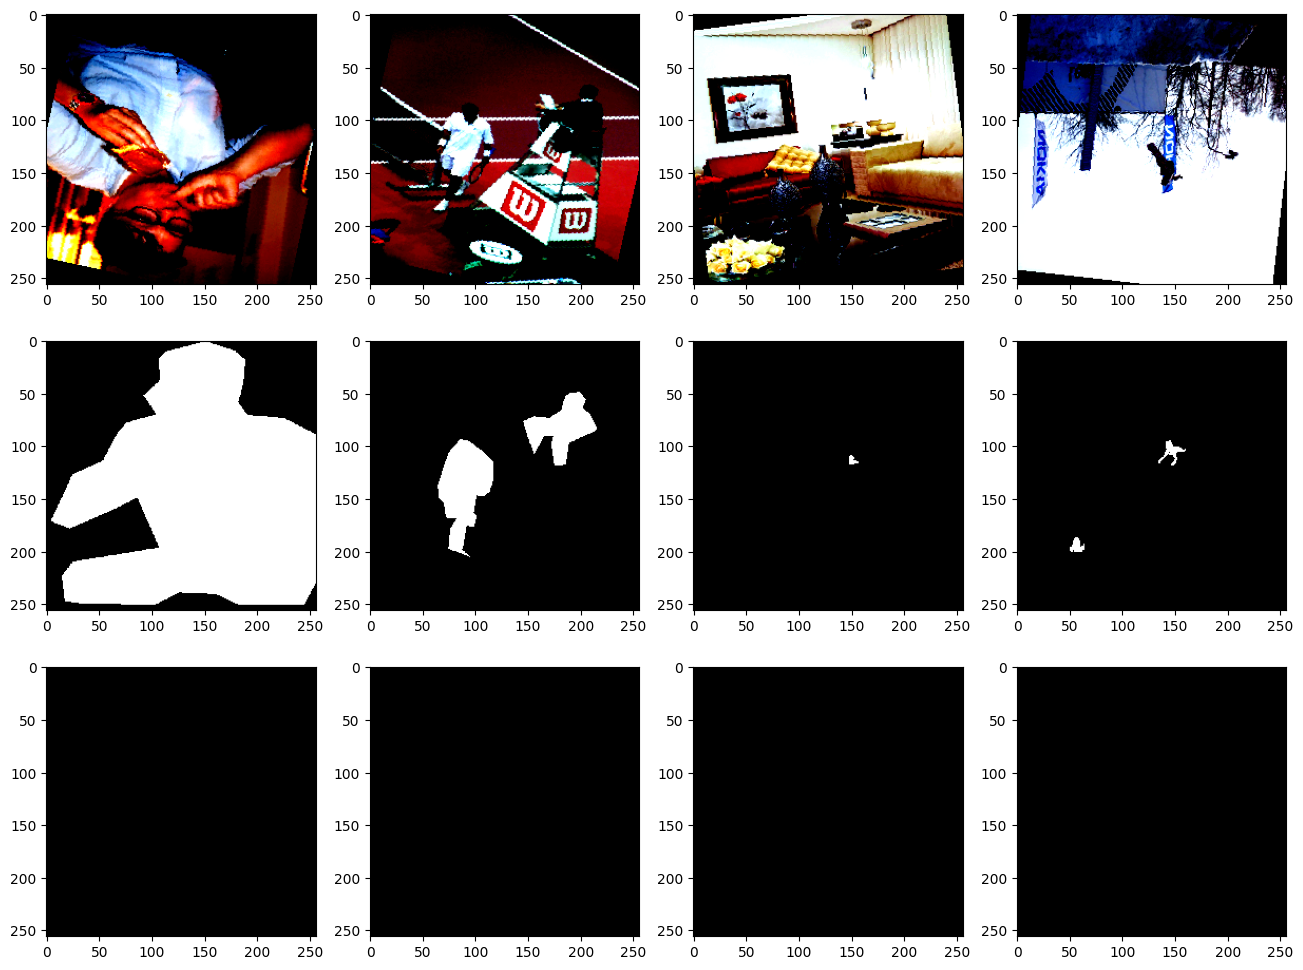

In [12]:
model.eval()

images, masks = next(iter(val_loader))

with torch.no_grad():

    outputs = model(images)

    preds = (
        torch.sigmoid(outputs) > 0.3
    ).float()

fig, axes = plt.subplots(
    3,4,
    figsize=(16,12)
)

for i in range(4):

    axes[0,i].imshow(
        images[i].permute(1,2,0)
    )

    axes[1,i].imshow(
        masks[i].squeeze(),
        cmap='gray'
    )

    axes[2,i].imshow(
        preds[i].squeeze(),
        cmap='gray'
    )

plt.show()

## 11. Learning Rate Experiment

Compare different learning rates.

In [ ]:
learning_rates = [1e-3,1e-4]

results = {}

for lr in learning_rates:

    temp_model = ImprovedUNet()

    temp_optimizer = optim.Adam(
        temp_model.parameters(),
        lr=lr
    )

    temp_criterion = nn.BCEWithLogitsLoss()

    losses = []

    for epoch in range(3):

        epoch_loss = 0

        for images, masks in train_loader:

            outputs = temp_model(images)

            loss = temp_criterion(
                outputs,
                masks
            )

            temp_optimizer.zero_grad()

            loss.backward()

            temp_optimizer.step()

            epoch_loss += loss.item()

        losses.append(epoch_loss)

    results[lr] = losses

print(results)